In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

## Convert Rej Sampling Data to SFT Data

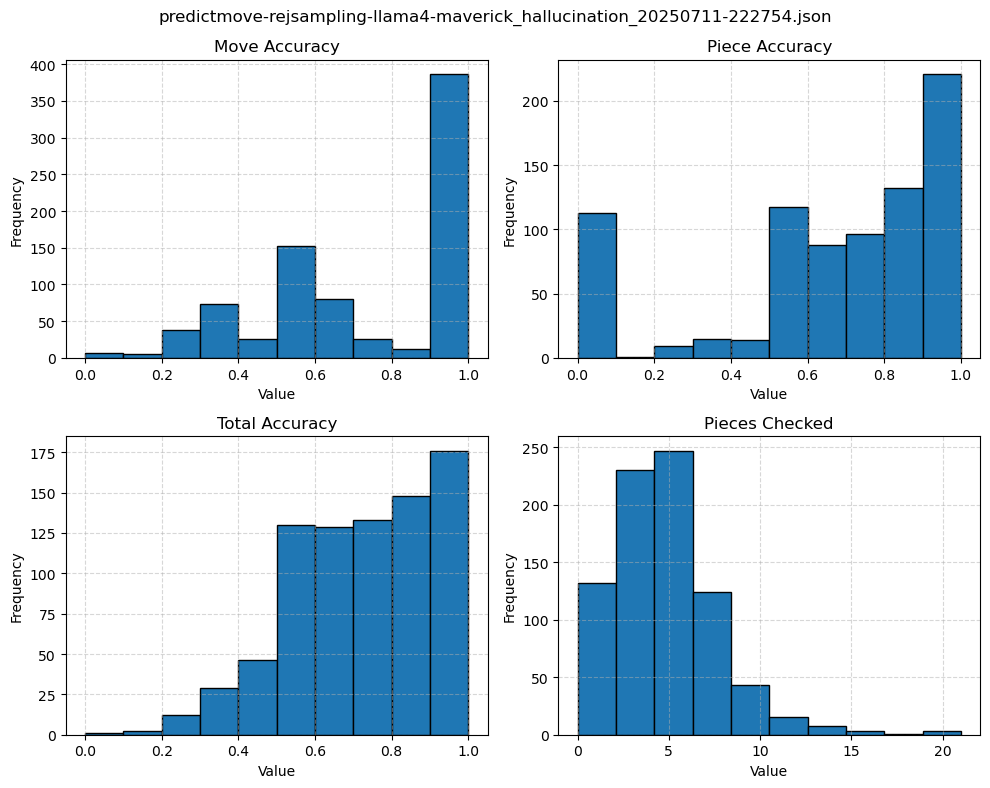

In [2]:
# ------------ config -------------------------------------------------
parent_dir = Path("model_outputs")
hallucinations_dir = parent_dir / "llama4_maverick-predictmove"
# hallucinations_dir = parent_dir / "kimi_k2-predictmove"

# ------------ helpers ------------------------------------------------
def safe_div(num: int | float, den: int | float) -> float:
    """Return num/den, guarding against division-by-zero."""
    return num / den if den else 0.0

# ------------ main ---------------------------------------------------
for jf in hallucinations_dir.glob("*.json"):
    with open(jf, "r", encoding="utf-8") as fh:
        records = json.load(fh)          # ~500 elements / file

    move_acc, piece_acc, total_acc, pieces_checked = [], [], [], []

    for rec in records:
        pr = rec["parsed_response"]
        mc, mchk = pr["Count: Moves Correct"], pr["Count: Moves Checked"]
        pc, pchk = pr["Count: Pieces Correct"], pr["Count: Pieces Checked"]

        move_acc.append(safe_div(mc, mchk))
        piece_acc.append(safe_div(pc, pchk))
        total_acc.append(safe_div(mc + pc, mchk + pchk))
        pieces_checked.append(mc + pc)   # “sum num of the two top ones”

    # -------- plot 4× histograms per JSON file -----------------------
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.ravel()
    metrics = [
        ("Move Accuracy", move_acc),
        ("Piece Accuracy", piece_acc),
        ("Total Accuracy", total_acc),
        ("Pieces Checked", pieces_checked),
    ]

    for ax, (title, values) in zip(axes, metrics):
        # add edgecolor for bin separation, histtype for bar style
        ax.hist(values, bins=10, edgecolor="black", histtype="bar")
        ax.set_title(title)
        ax.set_xlabel("Value")             # optional, improves clarity
        ax.set_ylabel("Frequency")
        ax.grid(True, linestyle="--", alpha=0.5)  # subtle grid for readability

    fig.suptitle(jf.name)
    fig.tight_layout()
    plt.show()
